In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.metrics import f1_score
from PIL import Image
from tensorflow.keras.preprocessing import image
import numpy as np
import time
import seaborn as sns
from sklearn.preprocessing import LabelBinarizer
from sklearn.svm import SVC
from lime import lime_image
from skimage.segmentation import mark_boundaries
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

In [2]:
photos_csv = r'C:\Users\Gurbachan\Desktop\CV_ASS2\image\photos.csv'
photos_folder = r'C:\Users\Gurbachan\Desktop\CV_ASS2\image\photos'
# Load dataset
df = pd.read_csv(photos_csv)

In [3]:
def bar_plot(data):
    class_counts = pd.Series(data).value_counts()

    # Plot bar chart
    class_counts.plot(kind="bar", color=["green", "red", "blue", "orange", "yellow"], edgecolor="black", figsize=(8, 6))

    # Add values on top of each bar
    for i, v in enumerate(class_counts):
        plt.text(i, v + 0.2, str(v), ha="center", fontsize=12)
        
        
    print("class_count : ", class_counts)
    # Customize plot
    plt.xlabel("Sentiment Labels")
    plt.ylabel("Frequency")
    plt.title("Sentiment Distribution in Traget ")
    plt.xticks(rotation=0)  # Keep labels readable
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Show the plot
    plt.show()

class_count :  label
food       40391
inside     21220
outside     6862
drink       5905
menu         622
Name: count, dtype: int64


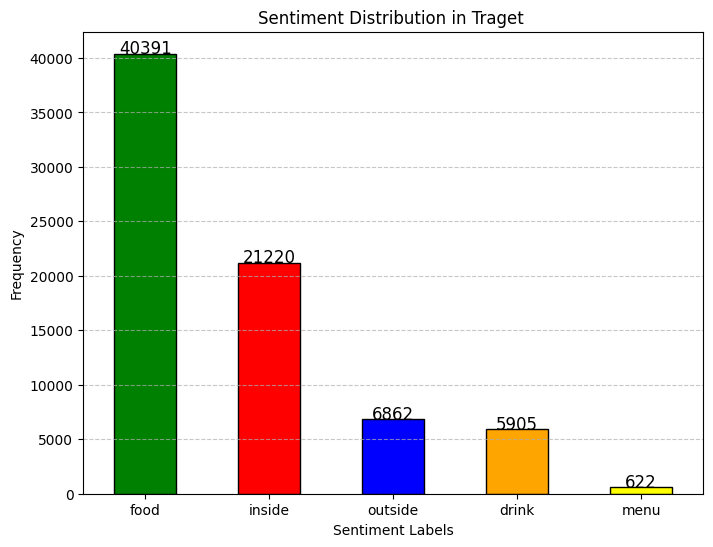

In [4]:
bar_plot(df['label'])

In [5]:
# Separate majority and minority classes
df_majority_food = df[df['label'] == 'food']
df_majority_inside = df[df['label'] == 'inside']
df_majority_outside = df[df['label'] == 'outside']
df_majority_drink = df[df['label'] == 'drink']
df_minority_menu = df[df['label'] == 'menu']

# Undersample majority classes to 600 samples each
df_majority_food_downsampled = resample(df_majority_food, replace=False, n_samples=300, random_state=42)
df_majority_inside_downsampled = resample(df_majority_inside, replace=False, n_samples=300, random_state=42)
df_majority_outside_downsampled = resample(df_majority_outside, replace=False, n_samples=300, random_state=42)
df_majority_drink_downsampled = resample(df_majority_drink, replace=False, n_samples=300, random_state=42)

# Oversample minority class to 600 samples
df_minority_menu_upsampled = resample(df_minority_menu, replace=True, n_samples=300, random_state=42)

# Combine all classes into a balanced DataFrame
df_balanced = pd.concat([df_majority_food_downsampled, df_majority_inside_downsampled, df_majority_outside_downsampled, df_majority_drink_downsampled, df_minority_menu_upsampled])

# Shuffle the DataFrame
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [6]:
df_balanced

,photo_id,label
0,U8HSBXtQqdqt6IpIcTYvug,drink
1,h9A8mlBuPq8i1_aZd7-8PQ,menu
2,YvD_Syf-p1NDC1lZ1O2tDA,inside
3,4EIwxjvh4wsPmE7FfezYLQ,inside
4,2PRUNYC7U8eH-NpJaADmFQ,inside
...,...,...
1495,ovDUur_DN_7LQum-7rlUqQ,drink
1496,HZExPSHo8X_yw4mDwsUDkA,menu
1497,JKN3a1y2QQBvqe4VI4mwyg,outside
1498,_MjV0GWbtmqn9EexSJv-jw,menu


class_count :  label
drink      300
menu       300
inside     300
outside    300
food       300
Name: count, dtype: int64


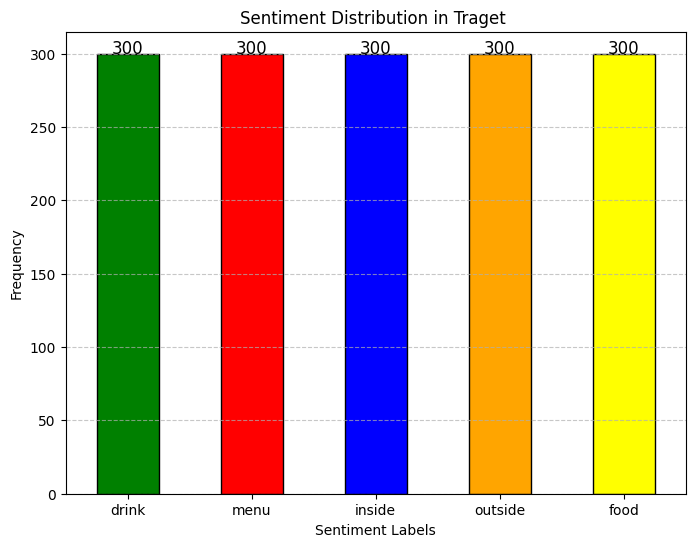

In [7]:
bar_plot(df_balanced['label'])

In [8]:
df = df_balanced

In [9]:
# Build a dictionary to map photo_id to the image file paths
photo_id_to_path = {}
for file in os.listdir(photos_folder):
    # Assuming the photo_id is in the file name (e.g., photo_id.jpg)
    photo_id = file.split('.')[0] # Adjust based on your file naming convention
    photo_id_to_path[photo_id] = os.path.join(photos_folder, file)

In [10]:
df.head(10)

,photo_id,label
0,U8HSBXtQqdqt6IpIcTYvug,drink
1,h9A8mlBuPq8i1_aZd7-8PQ,menu
2,YvD_Syf-p1NDC1lZ1O2tDA,inside
3,4EIwxjvh4wsPmE7FfezYLQ,inside
4,2PRUNYC7U8eH-NpJaADmFQ,inside
5,RIMQufgjmE2X39r5j_0o1A,outside
6,zLYtC8XyWa8wlvcfJStDeQ,drink
7,yZIWoD8rJ8hGbcDL_Pdl8Q,outside
8,bwt1dOjqDaRkoR4hJnb1Jw,menu
9,2fS7BKJWzSp51-iXceDtng,food


In [11]:
# Get the first 10 records from the dictionary
first_10_records = dict(list(photo_id_to_path.items())[:10])

# Print them
print("First 10 records:", first_10_records)

First 10 records: {'--0h6FMC0V8aMtKQylojEg': 'C:\\Users\\Gurbachan\\Desktop\\CV_ASS2\\image\\photos\\--0h6FMC0V8aMtKQylojEg.jpg', '--3JQ4MlO-jHT9xbo7liug': 'C:\\Users\\Gurbachan\\Desktop\\CV_ASS2\\image\\photos\\--3JQ4MlO-jHT9xbo7liug.jpg', '--3P3fjPrScy06XVLi4vhg': 'C:\\Users\\Gurbachan\\Desktop\\CV_ASS2\\image\\photos\\--3P3fjPrScy06XVLi4vhg.jpg', '--4DfhW2sJvjeC90KEDX3g': 'C:\\Users\\Gurbachan\\Desktop\\CV_ASS2\\image\\photos\\--4DfhW2sJvjeC90KEDX3g.jpg', '--5V3mRlhb3zqE5yF4Gpaw': 'C:\\Users\\Gurbachan\\Desktop\\CV_ASS2\\image\\photos\\--5V3mRlhb3zqE5yF4Gpaw.jpg', '--7SiWWk_OHbdmcU4pNDQw': 'C:\\Users\\Gurbachan\\Desktop\\CV_ASS2\\image\\photos\\--7SiWWk_OHbdmcU4pNDQw.jpg', '--8pNvGp9ICBjJVck2OnTQ': 'C:\\Users\\Gurbachan\\Desktop\\CV_ASS2\\image\\photos\\--8pNvGp9ICBjJVck2OnTQ.jpg', '--9cH8_rrskfmYvONaJpgQ': 'C:\\Users\\Gurbachan\\Desktop\\CV_ASS2\\image\\photos\\--9cH8_rrskfmYvONaJpgQ.jpg', '--9zKbcEd-DXH4ZUiEI4UA': 'C:\\Users\\Gurbachan\\Desktop\\CV_ASS2\\image\\photos\\--9zKbcEd-D

In [12]:
# Open the image
img = Image.open("C:\\Users\\Gurbachan\\Desktop\\CV_ASS2\\image\\photos\\__02nEL2xViYvZihvV4_hw.jpg")

# Get the image size (width, height)
width, height = img.size
print(f"Width: {width}, Height: {height}")

Width: 400, Height: 400


In [13]:
# Function to preprocess images (resize to 224x224 and normalize)
def preprocess_image(img_path, target_size=(224, 224)):
    try:
        img = image.load_img(img_path, target_size=target_size)
        img_array = image.img_to_array(img)
        return img_array / 255.0  # Normalize the image
    except Exception as e:
        print(f"Error occurred: {e}")
        print(f"Image path: {img_path}")
        return None

# Preprocess images for each photo_id
x_images = []
y_labels = []

for _, row in df.iterrows():
    photo_id = row['photo_id']
    label = row['label']
    
    # Get the image path based on the photo_id
    img_path = photo_id_to_path.get(photo_id)
    
    if img_path:
        # Preprocess the image
        img = preprocess_image(img_path)
        if(img is not None) :
            x_images.append(img)
            y_labels.append(label)

# Convert lists to numpy arrays for further processing
print(len(x_images))

x_images = np.array(x_images)

print(x_images)
print(y_labels)


print("\nShape of the image array: ", x_images.shape)
print("length of target: ", len(y_labels))

1500
[[[[0.6        0.6745098  0.83137256]
   [0.6        0.6745098  0.83137256]
   [0.6        0.6745098  0.83137256]
   ...
   [0.79607844 0.85882354 0.92156863]
   [0.79607844 0.85882354 0.92156863]
   [0.79607844 0.85882354 0.91764706]]

  [[0.6        0.6745098  0.83137256]
   [0.6        0.6745098  0.83137256]
   [0.6        0.6745098  0.83137256]
   ...
   [0.79607844 0.8627451  0.9254902 ]
   [0.79607844 0.8627451  0.9254902 ]
   [0.79607844 0.8627451  0.9254902 ]]

  [[0.6        0.6745098  0.83137256]
   [0.6        0.6745098  0.83137256]
   [0.6        0.6745098  0.83137256]
   ...
   [0.79607844 0.8627451  0.9254902 ]
   [0.79607844 0.8627451  0.9254902 ]
   [0.79607844 0.8627451  0.9254902 ]]

  ...

  [[0.6        0.41960785 0.31764707]
   [0.5882353  0.40784314 0.30588236]
   [0.5882353  0.40784314 0.30588236]
   ...
   [0.7254902  0.59607846 0.46666667]
   [0.73333335 0.6039216  0.4745098 ]
   [0.7529412  0.62352943 0.5019608 ]]

  [[0.5882353  0.40784314 0.3137255 ]
  

In [15]:
label_mapping = {'food' : 0, 'inside' : 1, 'outside' : 2, 'drink' : 3, 'menu' : 4}
reverse_label_mapping = {0 : 'food',1 : 'inside',2 : 'outside',3 : 'drink',4 : 'menu'}

In [16]:
# Map the labels using the custom dictionary
y = np.array([label_mapping[label] for label in y_labels])

# Flatten the images
x = x_images.reshape(x_images.shape[0], -1)

print("Shape of the image array: ",x.shape)
print("Shape of the target array: ",y.shape)

Shape of the image array:  (1500, 150528)
Shape of the target array:  (1500,)


In [17]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    
    cm = confusion_matrix(y_true, y_pred)
    
    # Step 2: Convert the confusion matrix to a DataFrame for better visualization
    cm_df = pd.DataFrame(cm, index=[reverse_label_mapping[i] for i in range(len(cm))], 
                         columns=[reverse_label_mapping[i] for i in range(len(cm))])
    
    print(cm_df)
    
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap="Blues", xticklabels=cm_df.columns, yticklabels=cm_df.columns)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

In [18]:
def plot_roc_curve(y_true, y_pred_bin):
     # Initialize LabelBinarizer
    lb = LabelBinarizer()

    # Binarize the true labels (one-hot encoding)
    y_true_bin = lb.fit_transform(y_true)   
    
    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(y_true_bin.shape[1]):  # Iterate through all classes
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves in one plot
    plt.figure(figsize=(10, 8))
    
    # Plot ROC for each class
    for i in range(y_true_bin.shape[1]):
        label = lb.classes_[i]
        plt.plot(fpr[i], tpr[i], label=f'{reverse_label_mapping[label]} (AUC = {roc_auc[i]:.2f})')

    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

    # Labeling and Title
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')

    # Show the plot
    plt.show()

    # Print AUC values for each class
    for i in range(y_true_bin.shape[1]):
        print(f'AUC for class {lb.classes_[i]}: {roc_auc[i]:.2f}')


In [19]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Shape of x_train: ",x_train.shape)
print("Shape of y_train: ",y_train.shape)

print("Shape of x_test: ",x_test.shape)
print("Shape of y_test: ",y_test.shape)

Shape of x_train:  (1200, 150528)
Shape of y_train:  (1200,)
Shape of x_test:  (300, 150528)
Shape of y_test:  (300,)


class_count :  4    244
3    242
2    240
1    240
0    234
Name: count, dtype: int64


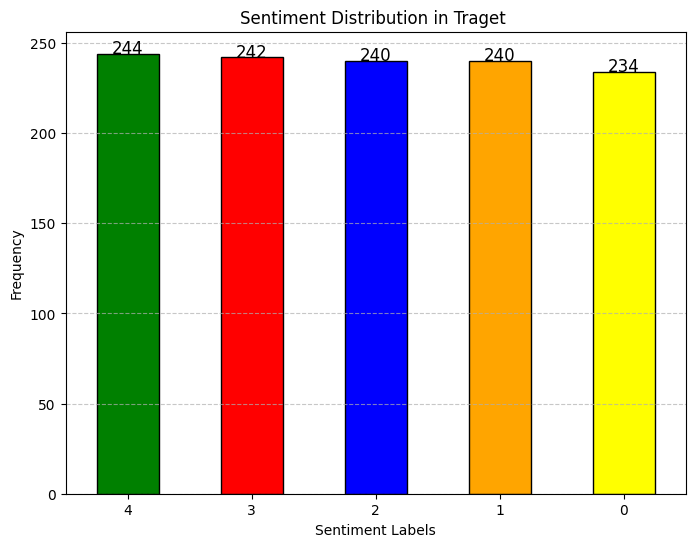

In [20]:
bar_plot(y_train)

In [21]:
# # Assuming X is your feature matrix and y is your target labels
# smote = SMOTE(random_state=42)
# x_resampled, y_resampled = smote.fit_resample(x_train, y_train)

# print("Shape of x_resampled: ",x_resampled.shape)
# print("Shape of y_resampled: ",y_resampled.shape)

In [22]:
# print("\nx_train : ", x_train)
# print("\ny_train : ", y_train)
# print("\nx_resampled : ", x_resampled)
# print("\ny_resampled : ", y_resampled)

In [23]:
# bar_plot(y_resampled)

In [24]:
def model_result(model, x_train, y_train, x_test, y_test):
    # Evaluate on Training Data
    y_train_pred = model.predict(x_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)

    # Evaluate on Testing Data
    y_test_pred = model.predict(x_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Classification report for train and test
#     train_classification_report = classification_report(y_train, y_train_pred)
#     test_classification_report = classification_report(y_test, y_test_pred)
    
    # Get predicted probabilities instead of class predictions
    y_pred_proba_test = model.predict_proba(x_test)
    y_pred_proba_train = model.predict_proba(x_train)

    # Confusion Matrix for train and test
    train_conf_matrix = confusion_matrix(y_train, y_train_pred)
    test_conf_matrix = confusion_matrix(y_test, y_test_pred)

    # Print results for train data
    print(f"\nTraining Accuracy: {train_accuracy * 100:.2f}%")
    print(f"\nConfusion matrix Train:\n ", train_conf_matrix)
    # F1 scores for train data
    f1_train = f1_score(y_train, y_train_pred, average=None)
    print("\nF1 Scores for each class:")
    for i, score in enumerate(f1_train):
        print(f"{reverse_label_mapping[i]}: {score:.4f}")
#     print("\nTraining Classification Report:")
#     print(train_classification_report)
    plot_confusion_matrix(y_train, y_train_pred)
    plot_roc_curve(y_train, y_pred_proba_train)

    # Print results for test data
    print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
    print(f"\nConfusion matrix Test:\n ", test_conf_matrix)
    # F1 scores for test data
    f1_test = f1_score(y_test, y_test_pred, average=None)
    print("\nF1 Scores for each class:")
    for i, score in enumerate(f1_test):
        print(f"{reverse_label_mapping[i]}: {score:.4f}")
#     print("\nTest Classification Report:")
#     print(test_classification_report)
    plot_confusion_matrix(y_test, y_test_pred)
    plot_roc_curve(y_test, y_pred_proba_test)

In [26]:
def explain_with_lime(flattened_image, model, original_shape=(224, 224, 3), top_labels=5, num_samples= 500, num_features=5):
    """
    Explain the prediction of a k-NN model trained on flattened image data using LIME.

    Parameters:
    - flattened_image (numpy array): Flattened image array (1D).
    - knn_model: Trained k-NN model (must have a `predict_proba` method).
    - original_shape (tuple): Original shape of the image (height, width, channels).
    - top_labels (int): Number of top labels to explain (default: 5).
    - num_samples (int): Number of samples to generate for LIME (default: 1000).
    - num_features (int): Number of features to highlight in the explanation (default: 5).

    Returns:
    - explanation: LIME explanation object.
    - visualization: Image with highlighted regions.
    """
    
    # Reshape the flattened image back to its original shape
    image = flattened_image.reshape(original_shape)
    
    flat_image = image.reshape(1, -1)
    predicted_class = model.predict(flat_image)  # Predicted class
    print(f"The image belongs to class: {predicted_class}")

    # Create a wrapper function for k-NN predict_proba
    def model_predict_proba(images):
        """
        Reshape the images to 2D and predict probabilities using the k-NN model.
        """
        # Flatten the images
        
        flattened_images = images.reshape(images.shape[0], -1)  # Shape: (n_samples, height * width * channels)
        # Predict probabilities
        return model.predict_proba(flattened_images)

    # Create LIME explainer
    explainer = lime_image.LimeImageExplainer()

    # Explain the model's prediction on the image
    explanation = explainer.explain_instance(
        image, 
        model_predict_proba, 
        top_labels=top_labels, 
        hide_color=0, 
        num_samples=num_samples
    )

    # Get the explanation for the top predicted label
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], 
        positive_only=True, 
        num_features=num_features, 
        hide_rest=False
    )

    # Visualize the explanation
    visualization = mark_boundaries(temp / 2 + 0.5, mask)
    plt.imshow(visualization)
    plt.axis('off')  # Hide axes
    plt.show()

    return explanation, visualization

Training Time: 1.30 seconds

Training Accuracy: 62.92%

Confusion matrix Train:
  [[187   1   3  35   8]
 [ 93 117  11  17   2]
 [ 67  20 136  14   3]
 [ 62  15   8 152   5]
 [ 46  12  17   6 163]]

F1 Scores for each class:
food: 0.5428
inside: 0.5778
outside: 0.6554
drink: 0.6524
menu: 0.7671
         food  inside  outside  drink  menu
food      187       1        3     35     8
inside     93     117       11     17     2
outside    67      20      136     14     3
drink      62      15        8    152     5
menu       46      12       17      6   163


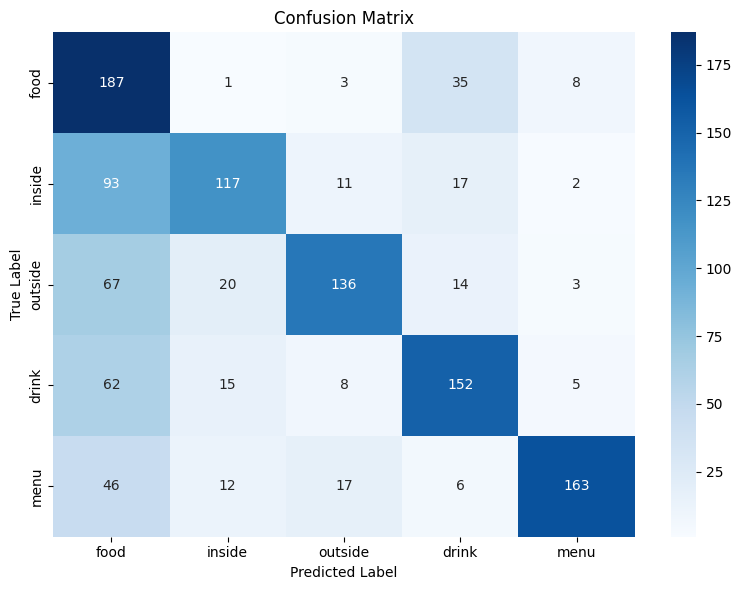

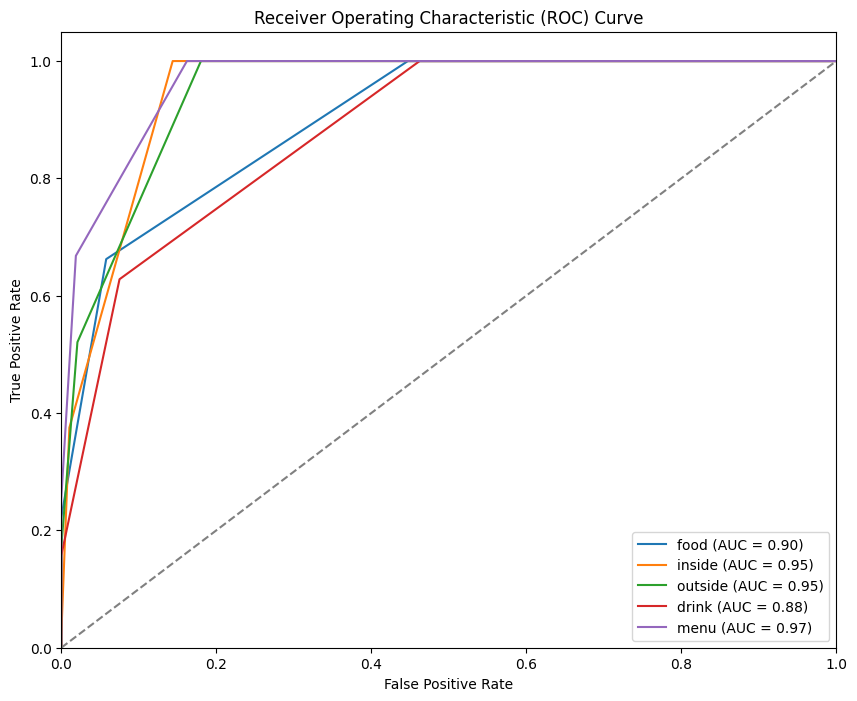

AUC for class 0: 0.90
AUC for class 1: 0.95
AUC for class 2: 0.95
AUC for class 3: 0.88
AUC for class 4: 0.97

Test Accuracy: 39.00%

Confusion matrix Test:
  [[33  4  2 18  9]
 [22 19  7  9  3]
 [20  6 23  7  4]
 [20  5  7 23  3]
 [15  9  5  8 19]]

F1 Scores for each class:
food: 0.3750
inside: 0.3689
outside: 0.4423
drink: 0.3740
menu: 0.4043
         food  inside  outside  drink  menu
food       33       4        2     18     9
inside     22      19        7      9     3
outside    20       6       23      7     4
drink      20       5        7     23     3
menu       15       9        5      8    19


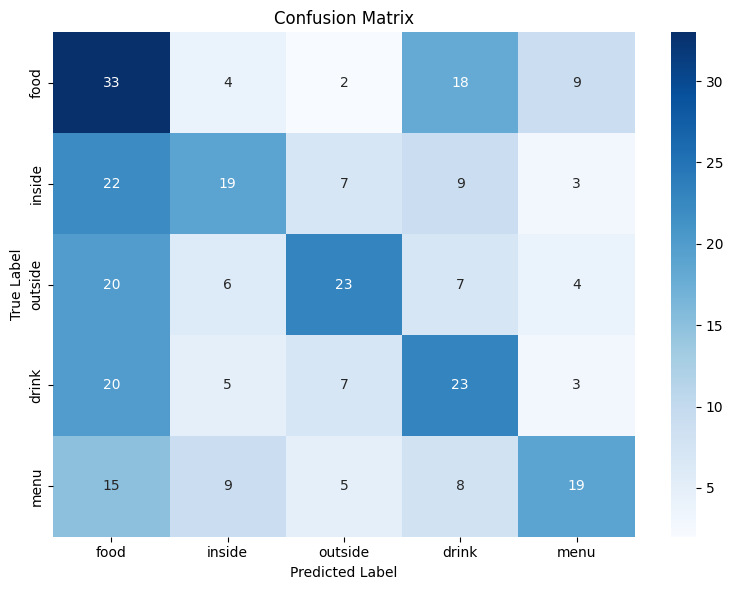

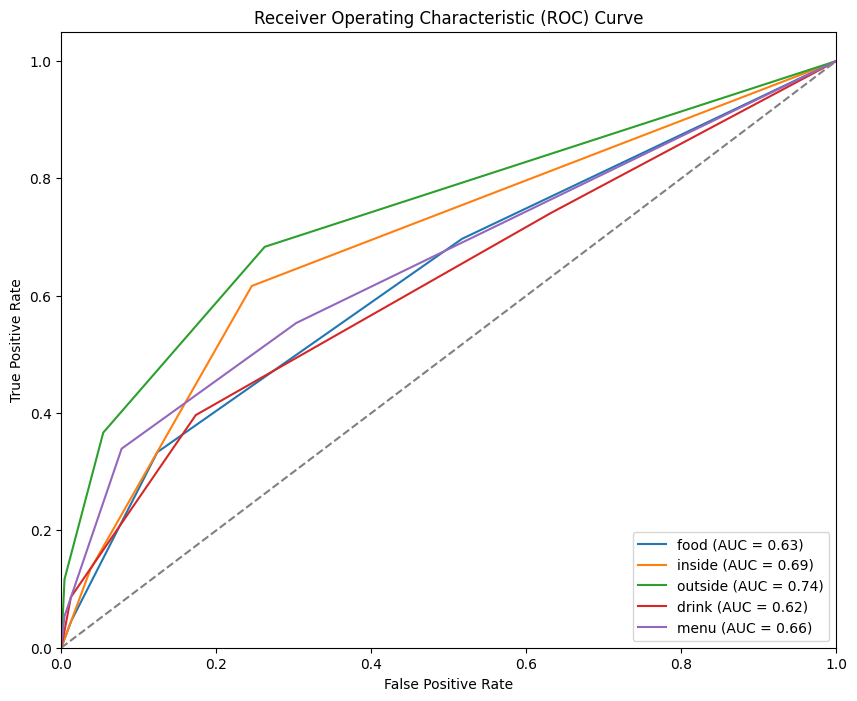

AUC for class 0: 0.63
AUC for class 1: 0.69
AUC for class 2: 0.74
AUC for class 3: 0.62
AUC for class 4: 0.66


In [27]:
# Initialize the KNN model with k=3
knn = KNeighborsClassifier(n_neighbors=3)


start_time = time.time()
# Train the KNN model
knn.fit(x_train, y_train)
end_time = time.time()

# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

model_result(knn, x_train, y_train, x_test, y_test)

In [28]:
print(x_test)
print(y_test)

print(x_test[0].shape)

# print(x_images)
# print(y_labels)

[[0.3254902  0.32156864 0.3019608  ... 0.40392157 0.41568628 0.3882353 ]
 [0.3647059  0.5176471  0.7490196  ... 0.84705883 0.8156863  0.77254903]
 [0.2784314  0.07058824 0.03921569 ... 0.75686276 0.6313726  0.47058824]
 ...
 [0.9843137  0.91764706 0.8901961  ... 0.92156863 0.70980394 0.46666667]
 [0.7411765  0.7176471  0.7254902  ... 0.77254903 0.7882353  0.8352941 ]
 [0.41960785 0.5529412  0.54901963 ... 0.09803922 0.06666667 0.05882353]]
[0 2 0 0 1 3 0 2 3 3 3 0 0 0 1 2 1 2 0 1 3 3 4 0 3 1 0 0 2 1 4 1 4 2 4 1 1
 0 3 2 1 3 2 3 1 3 3 1 1 4 4 1 1 4 1 0 3 1 2 4 2 0 0 3 4 4 1 2 1 4 4 3 3 4
 0 2 1 3 0 1 3 4 2 0 4 1 2 2 2 0 1 3 4 1 0 1 3 1 0 4 1 0 3 3 0 3 3 3 4 0 1
 2 0 1 0 1 3 3 1 0 1 3 2 2 0 4 4 2 4 0 4 1 0 4 0 4 4 0 1 2 4 0 3 4 1 3 2 2
 2 0 3 3 0 1 2 3 3 0 2 2 0 3 0 3 2 3 1 4 2 4 1 4 1 0 4 4 2 0 2 2 4 4 1 4 2
 4 2 4 4 2 0 1 2 4 1 4 4 4 1 2 2 1 0 0 0 1 4 0 1 3 0 2 3 2 0 3 2 3 4 2 3 2
 2 1 4 2 3 0 0 3 3 2 3 4 0 2 3 0 3 1 4 1 4 1 3 0 1 2 3 1 0 1 3 3 2 0 3 0 0
 0 2 4 0 4 0 2 1 1 2 1 3 1 3 2 

The image belongs to class: [4]


  0%|          | 0/500 [00:00<?, ?it/s]

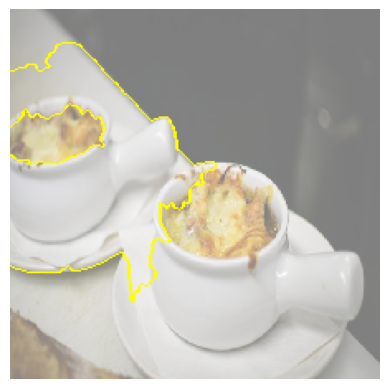

(<lime.lime_image.ImageExplanation at 0x2452c08d2e0>,
 array([[[0.6627451 , 0.6607843 , 0.6509804 ],
         [0.6666667 , 0.6647059 , 0.654902  ],
         [0.66862744, 0.6666667 , 0.65686274],
         ...,
         [0.5       , 0.5       , 0.5       ],
         [0.5       , 0.5       , 0.5       ],
         [0.5       , 0.5       , 0.5       ]],
 
        [[0.6647059 , 0.6627451 , 0.65294117],
         [0.66862744, 0.6666667 , 0.65686274],
         [0.67058825, 0.66862744, 0.65882355],
         ...,
         [0.5       , 0.5       , 0.5       ],
         [0.5       , 0.5       , 0.5       ],
         [0.5       , 0.5       , 0.5       ]],
 
        [[0.6666667 , 0.6647059 , 0.654902  ],
         [0.67058825, 0.66862744, 0.65882355],
         [0.672549  , 0.67058825, 0.6607843 ],
         ...,
         [0.5       , 0.5       , 0.5       ],
         [0.5       , 0.5       , 0.5       ],
         [0.5       , 0.5       , 0.5       ]],
 
        ...,
 
        [[0.64705884, 0.6039216 , 

In [29]:
explain_with_lime(x_test[0], knn)

In [30]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV / HalvingGridSearchCV for larger searches
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_curve, roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# -------------------------------
# 1. Set up the pipeline with scaling and KNN.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(algorithm='auto'))  # you can experiment with 'ball_tree' or 'kd_tree'
])

# -------------------------------
# 2. Define a parameter grid for the classifier within the pipeline.
# Note: Use the step name 'knn' as a prefix to the parameter names.
param_grid = {
    'knn__n_neighbors': [3, 7, 11],
    'knn__metric': ['euclidean', 'manhattan']
}

# -------------------------------
# 3. Create the GridSearchCV object.
#    - Reduce cv folds to 3 if run time is a concern.
#    - n_jobs=-1 utilizes all available processors.
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy',
                           n_jobs=-1, verbose=1)

# -------------------------------
# 4. Time the grid search fitting process.
start_time = time.time()
grid_search.fit(x_train, y_train)
end_time = time.time()

training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds\n")

# -------------------------------
# 5. Display the best parameters and best cross-validation score.
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}\n")

# Get the best model (including scaling) from the grid search.
best_model = grid_search.best_estimator_

# -------------------------------
# 6. Define a helper function to evaluate the model.
def model_result(model, X_train, y_train, X_test, y_test):
    # Predictions on training and test sets.
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate and print accuracies.
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    print("Training Accuracy:", train_acc)
    print("Test Accuracy:", test_acc, "\n")
    
    # Print classification report for test set.
    print("Classification Report (Test):")
    print(classification_report(y_test, y_test_pred))
    
    # Compute and plot confusion matrix.
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Predicted 0", "Predicted 1"],
                yticklabels=["Actual 0", "Actual 1"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()
    
    # Plot ROC curve and compute AUC (for binary classification).
    if hasattr(model, "predict_proba"):
        # Get the probabilities for the positive class.
        y_test_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
        auc_score = roc_auc_score(y_test, y_test_prob)
        print(f"ROC AUC Score: {auc_score:.4f}")
        
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, color="darkorange", lw=2,
                 label=f"ROC curve (area = {auc_score:.2f})")
        plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Receiver Operating Characteristic (ROC) Curve")
        plt.legend(loc="lower right")
        plt.show()
    else:
        print("Model does not support probability predictions.")

# -------------------------------
# 7. Evaluate the best model using the helper function.
model_result(best_model, x_train, y_train, x_test, y_test)


Fitting 3 folds for each of 6 candidates, totalling 18 fits


MemoryError: Unable to allocate 459. MiB for an array with shape (800, 150528) and data type float32

In [ ]:
# Create the SVM model with RBF kernel
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)

start_time = time.time()
svm_model.fit(x_train, y_train)
end_time = time.time()

# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

model_result(svm_model, x_train, y_train, x_test, y_test)

In [ ]:
param_grid = {
    'C': [0.1, 10],  # Test values for C
    'gamma': [0.01, 0.1],  # Test values for gamma
    'kernel': ['rbf']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=SVC(probability=True), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

start_time = time.time()
# Fit the model to the training data
grid_search.fit(x_train, y_train)
end_time = time.time()

# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

# Display the best parameters from GridSearch
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Get the best model after GridSearch
best_svm = grid_search.best_estimator_

model_result(best_svm, x_train, y_train, x_test, y_test)

In [ ]:
print(x_images)
print(y)

print(x_images.shape)
print(y.shape)

In [ ]:
# Split data
X_train, X_val, Y_train, Y_val = train_test_split(x_images, y, test_size=0.2, random_state=42)

In [ ]:
# Build CNN model
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(5, activation='softmax')  # 5 classes
])

# Compile the model
if y.ndim == 1:  # Sparse categorical crossentropy
    cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
else:  # Categorical crossentropy
    cnn_model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

start_time = time.time()
# Train the model
history = cnn_model.fit(X_train, Y_train, epochs=10, batch_size=32, validation_data=(X_val, Y_val))
end_time = time.time()

# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

# Evaluate
val_loss, val_accuracy = cnn_model.evaluate(X_val, Y_val)
print(f'Validation Accuracy: {val_accuracy:.4f}')

# Calculate Train and Test Accuracy
train_loss, train_accuracy = cnn_model.evaluate(X_train, Y_train, verbose=0)
test_loss, test_accuracy = cnn_model.evaluate(X_val, Y_val, verbose=0)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Confusion Matrix
# Predict classes for training and test data
y_train_pred = np.argmax(cnn_model.predict(X_train), axis=1)
y_test_pred = np.argmax(cnn_model.predict(X_val), axis=1)

# Convert one-hot encoded labels back to integers for confusion matrix
y_train_true = np.argmax(Y_train, axis=1) if Y_train.ndim > 1 else Y_train
y_test_true = np.argmax(Y_val, axis=1) if Y_val.ndim > 1 else Y_val

# Compute confusion matrix
train_cm = confusion_matrix(y_train_true, y_train_pred)
test_cm = confusion_matrix(y_test_true, y_test_pred)

# Plot confusion matrix for training data
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Train Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

# Plot confusion matrix for test data
plt.subplot(1, 2, 2)
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve and AUC
# Predict probabilities for each class
y_train_prob = cnn_model.predict(X_train)
y_test_prob = cnn_model.predict(X_val)

# Compute ROC curve and AUC for each class
plt.figure(figsize=(10, 8))
for i in range(5):  # Assuming 5 classes
    # Train ROC
    fpr_train, tpr_train, _ = roc_curve(y_train_true == i, y_train_prob[:, i])
    auc_train = roc_auc_score(y_train_true == i, y_train_prob[:, i])
    
    # Test ROC
    fpr_test, tpr_test, _ = roc_curve(y_test_true == i, y_test_prob[:, i])
    auc_test = roc_auc_score(y_test_true == i, y_test_prob[:, i])
    
    # Plot ROC curves
    plt.plot(fpr_train, tpr_train, label=f'Train Class {i} (AUC = {auc_train:.2f})')
    plt.plot(fpr_test, tpr_test, label=f'Test Class {i} (AUC = {auc_test:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()